In [3]:
import zipfile
z = zipfile.ZipFile("archive.zip")
z.extractall()

In [1]:
import PIL
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
image = PIL.Image.open("./chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg")

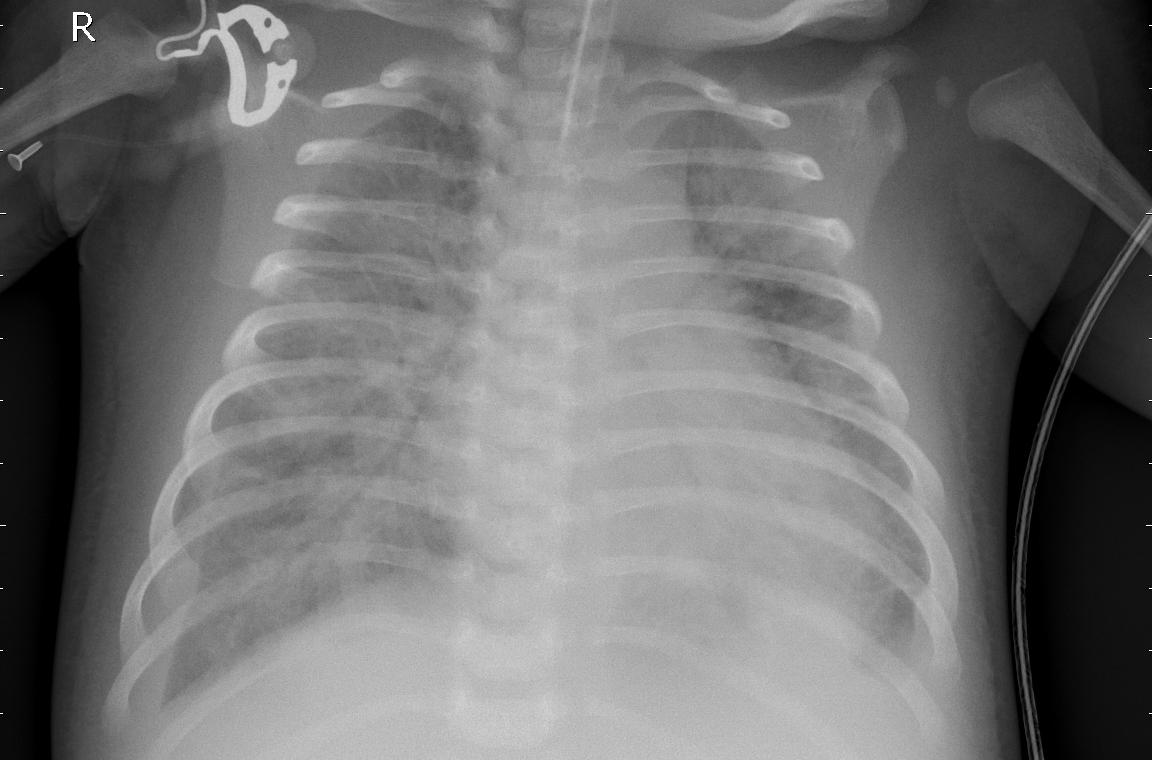

In [9]:
image

In [11]:
image_normal = PIL.Image.open("./chest_xray/train/NORMAL/IM-0280-0001.jpeg")

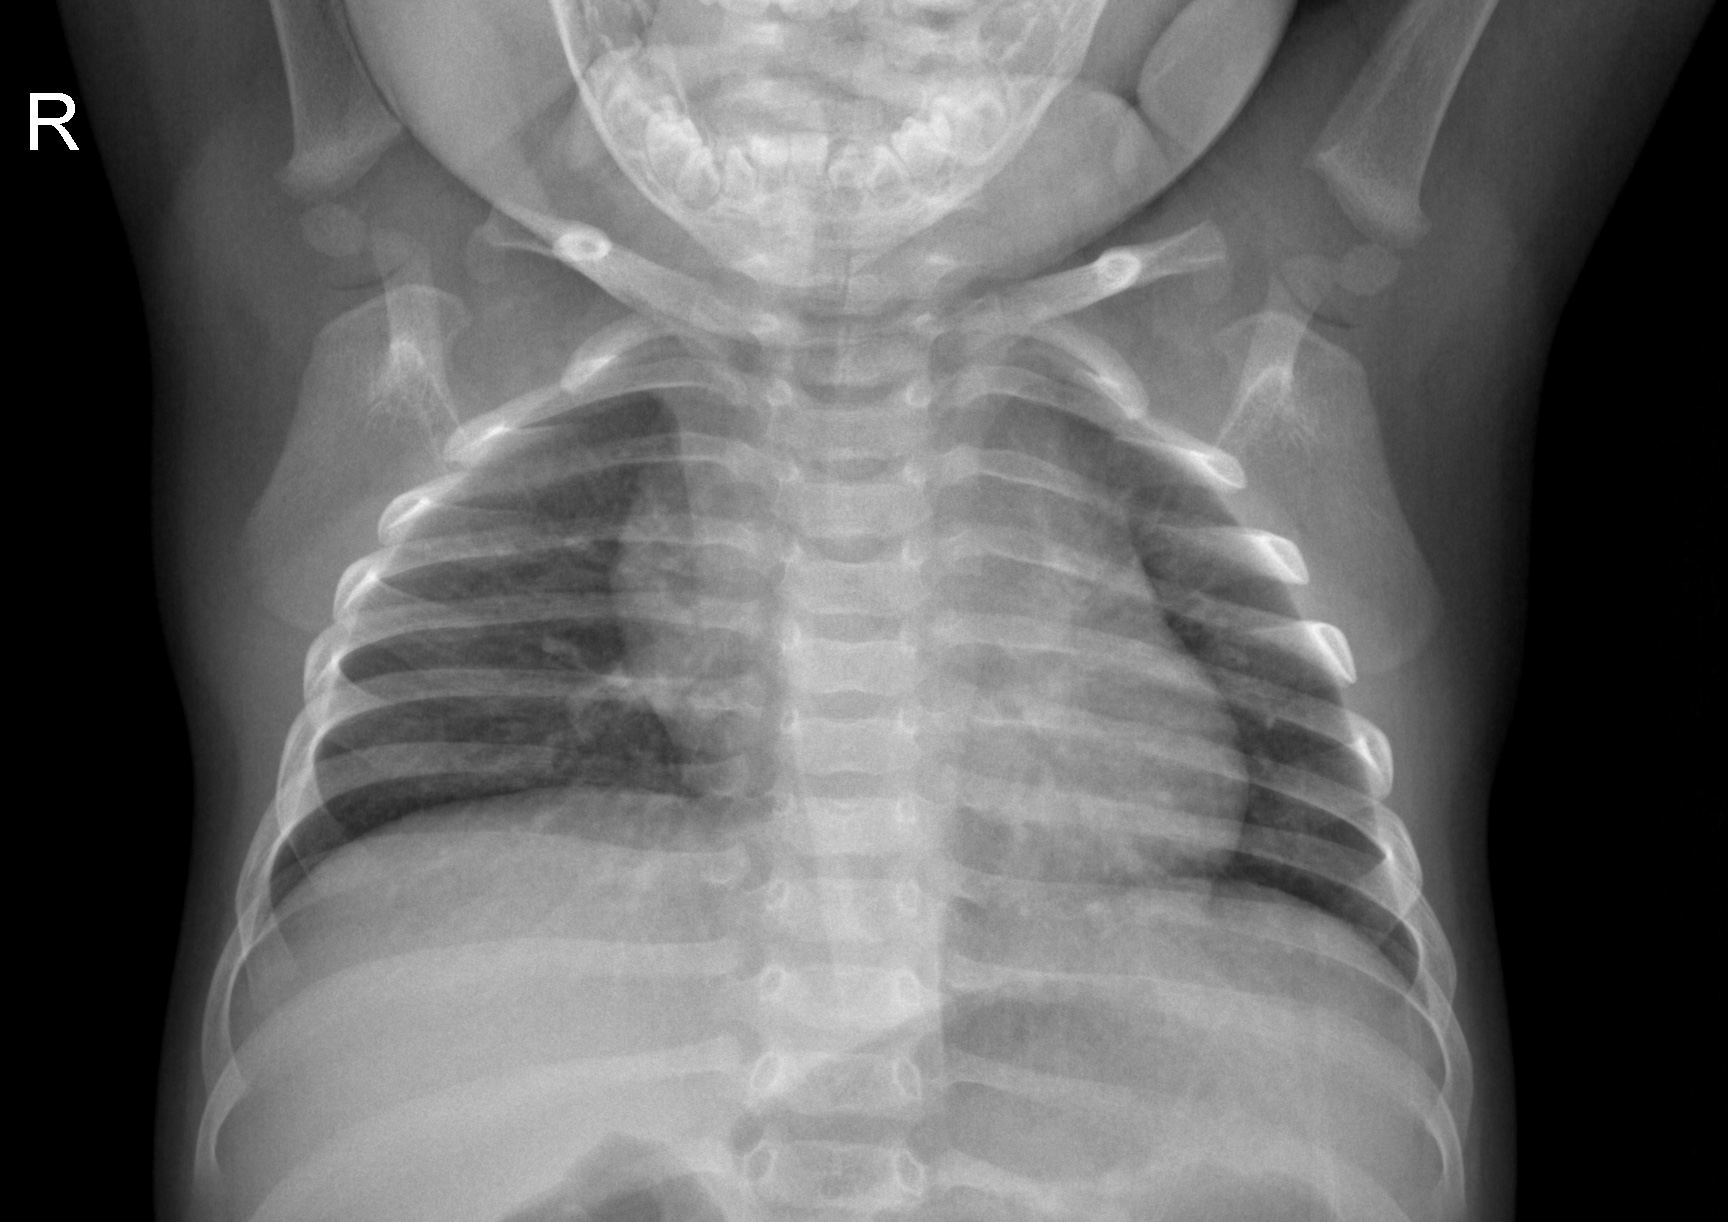

In [13]:
image_normal

In [ ]:
from keras.preprocessing.image import ImageDataGenerator

In [21]:
training_dir = "./chest_xray/train/"
training_generator = ImageDataGenerator(rescale=1/255)
data_train = training_generator.flow_from_directory(training_dir, target_size=(120,120), batch_size=8, class_mode="binary")

Found 5218 images belonging to 2 classes.


In [22]:
valid_dir = "./chest_xray/val/"
validation_generator = ImageDataGenerator(rescale=1/255)
data_valid = validation_generator.flow_from_directory(valid_dir, target_size=(120,120), batch_size=8, class_mode="binary")

Found 16 images belonging to 2 classes.


In [23]:
test_dir = "./chest_xray/test/"
test_generator = ImageDataGenerator(rescale=1/255)
data_test = test_generator.flow_from_directory(test_dir, target_size=(120,120), batch_size=8, class_mode="binary")

Found 625 images belonging to 2 classes.


# CONVOLUTIONAL NEURAL NETWORK

In [16]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.Input(shape=(120, 120, 3)),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(256, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(512, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 118, 118, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 59, 59, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 57, 57, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,700,161 (6.49 MB)

 Trainable params: 1,700,161 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["acc"])

In [ ]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',   # Which metric to monitor
    patience=3,           # How many epochs to wait after last improvement
    restore_best_weights=True  # Restore model weights from the best epoch
)

history = model.fit(
    epochs=10,
    validation_data=data_valid,
    callbacks=[early_stop]
)

In [ ]:
model.evaluate(data_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 267ms/step - acc: 0.8192 - loss: 0.7439


[0.743879497051239, 0.8191999793052673]

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])


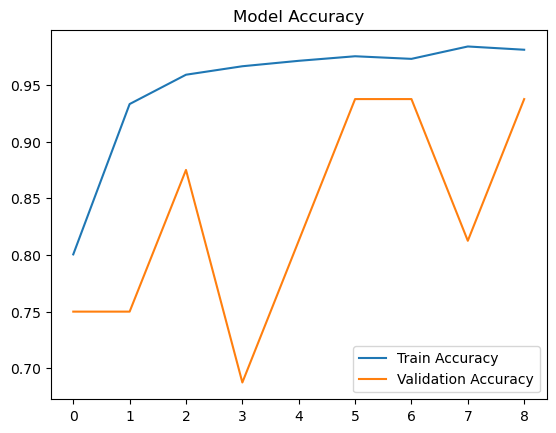

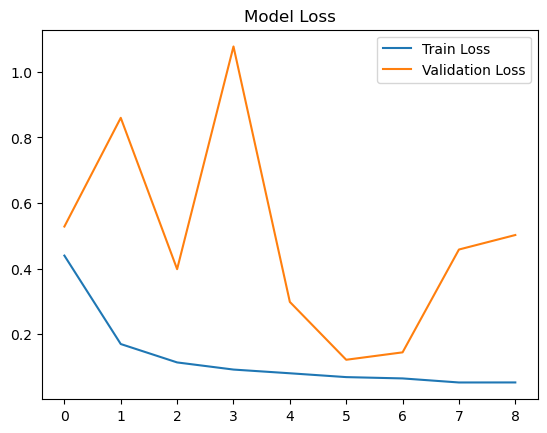

In [35]:
print(history.history.keys())

# Plot training & validation accuracy
plt.plot(history.history['acc'], label='Train Accuracy')
plt.plot(history.history['val_acc'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

In [37]:
predictions= model.predict(data_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step


In [215]:
predictions

array([[9.99999762e-01],
       [9.04699136e-03],
       [9.99985933e-01],
       [1.00000000e+00],
       [2.33380403e-02],
       [9.99773562e-01],
       [9.99954224e-01],
       [9.62938070e-01],
       [3.82790923e-01],
       [9.72086728e-01],
       [6.92173094e-03],
       [6.09007716e-01],
       [9.99985933e-01],
       [9.99999881e-01],
       [9.92038190e-01],
       [9.95313704e-01],
       [1.88277319e-01],
       [1.58354923e-01],
       [9.99992728e-01],
       [9.99999821e-01],
       [9.99992371e-01],
       [9.99999940e-01],
       [2.92837061e-02],
       [9.99986410e-01],
       [9.99988854e-01],
       [9.99998868e-01],
       [4.10134554e-01],
       [2.37447699e-03],
       [9.50847924e-01],
       [9.99999642e-01],
       [9.64638650e-01],
       [9.98800218e-01],
       [4.68888909e-01],
       [9.99721289e-01],
       [9.99999881e-01],
       [9.99995708e-01],
       [9.36824679e-01],
       [9.99998152e-01],
       [9.98313785e-01],
       [9.98416305e-01],


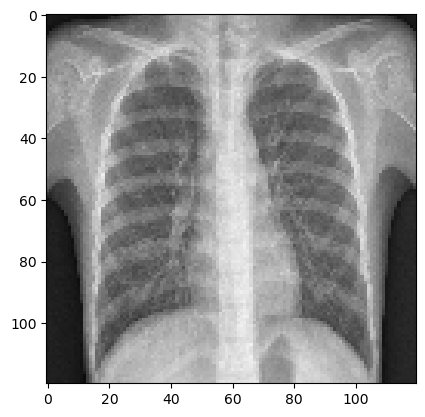

The pobability of pneumonia is:  [0.9762439]


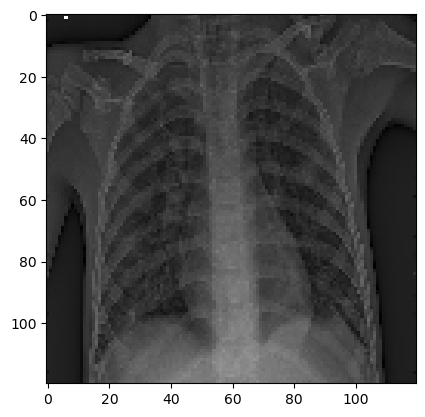

The pobability of pneumonia is:  [0.9999977]


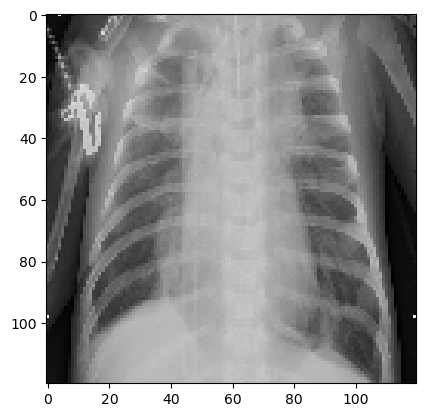

The pobability of pneumonia is:  [0.99998975]


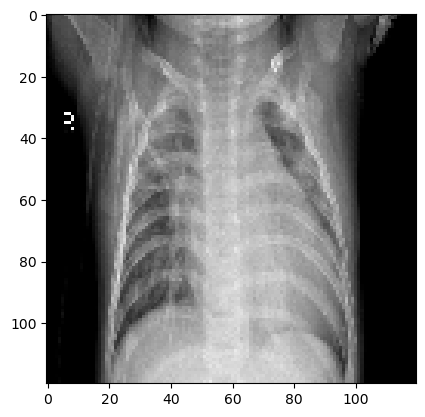

The pobability of pneumonia is:  [0.999991]


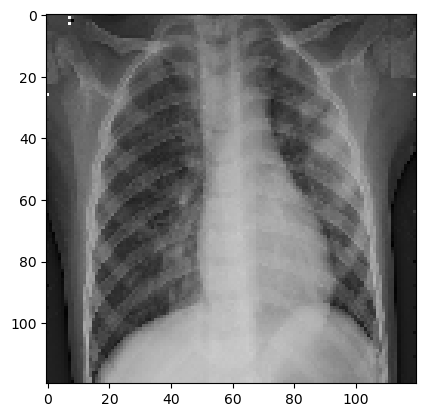

The pobability of pneumonia is:  [0.99999994]


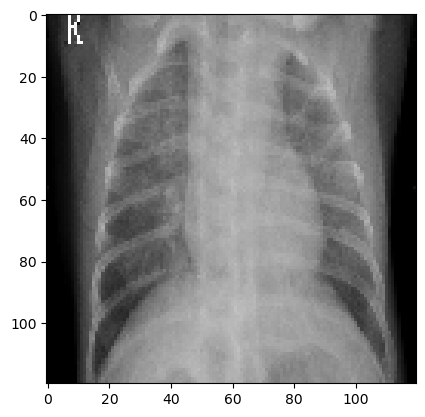

The pobability of pneumonia is:  [0.90608054]


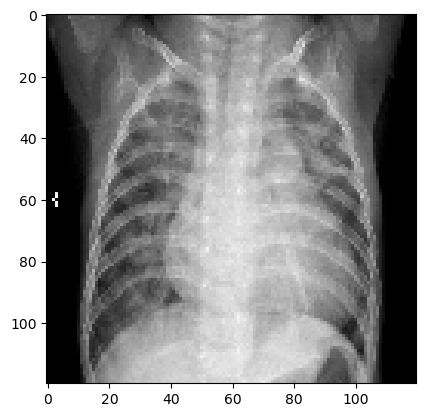

The pobability of pneumonia is:  [0.9996314]


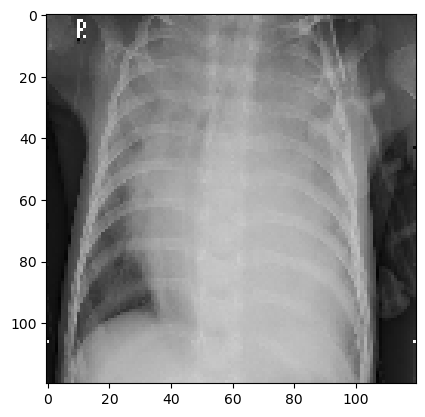

The pobability of pneumonia is:  [0.9999027]


In [39]:
x=next(data_test)
for i in range(0,1):
    image=x[i]
    for j in range(0,8):
        plt.imshow(image[j])
        plt.show()
        print("The pobability of pneumonia is: ",predictions[j])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


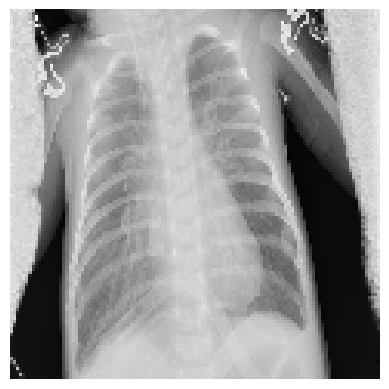

Actual: Pneumonia
Predicted: Pneumonia (100.00%)


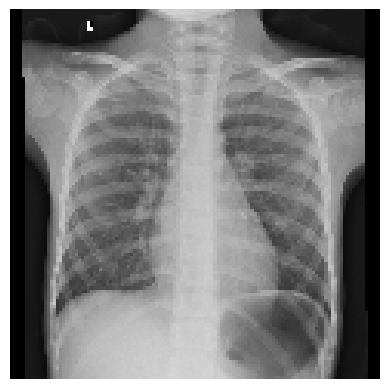

Actual: Normal
Predicted: Normal (43.73%)


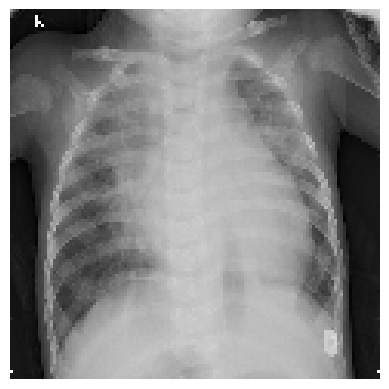

Actual: Pneumonia
Predicted: Pneumonia (100.00%)


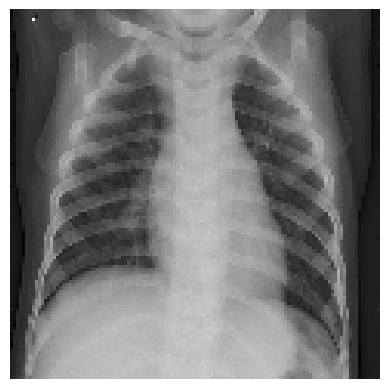

Actual: Normal
Predicted: Pneumonia (88.11%)


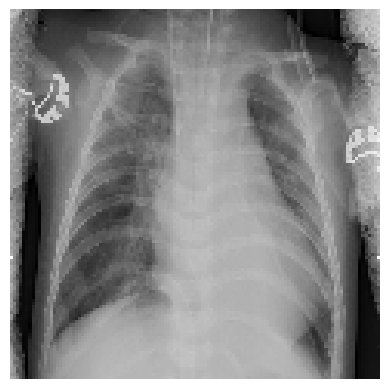

Actual: Pneumonia
Predicted: Pneumonia (99.99%)


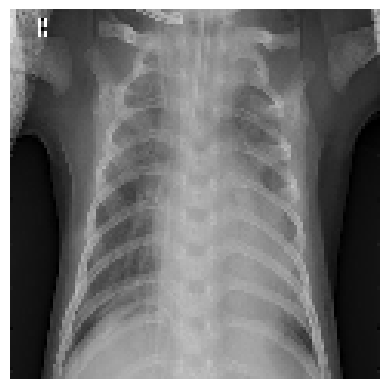

Actual: Pneumonia
Predicted: Pneumonia (100.00%)


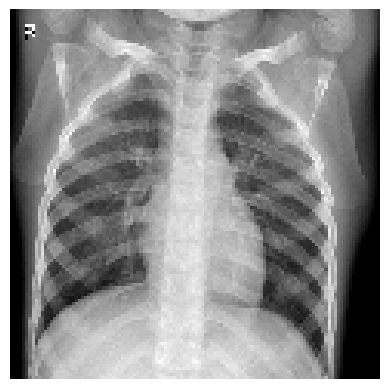

Actual: Normal
Predicted: Normal (45.63%)


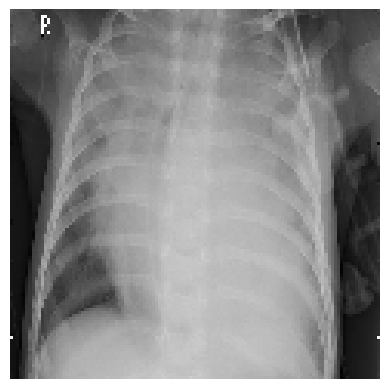

Actual: Pneumonia
Predicted: Pneumonia (100.00%)


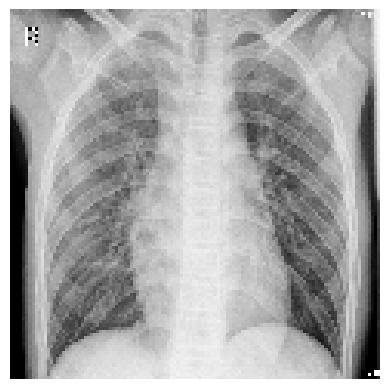

Actual: Normal
Predicted: Pneumonia (100.00%)


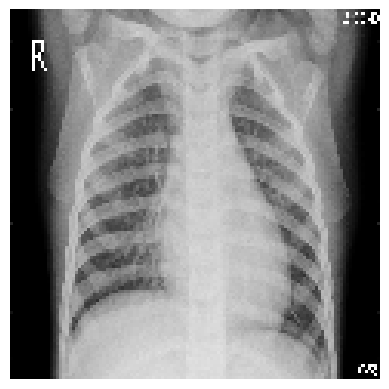

Actual: Pneumonia
Predicted: Pneumonia (99.93%)


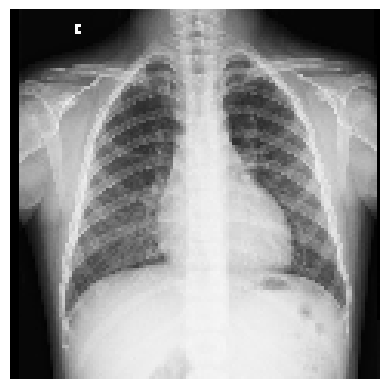

Actual: Normal
Predicted: Normal (0.14%)


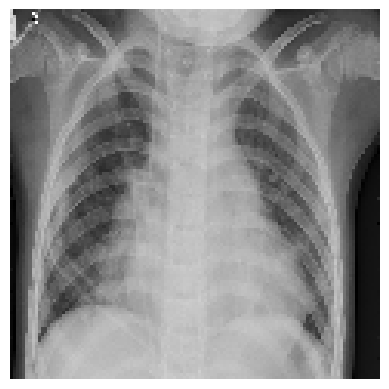

Actual: Pneumonia
Predicted: Pneumonia (99.98%)


In [138]:
import numpy as np

# Get first batch
images_batch_1, labels_batch_1 = next(data_test)

# Get second batch
images_batch_2, labels_batch_2 = next(data_test)

# Combine batches
images_batch = np.concatenate((images_batch_1, images_batch_2), axis=0)[:12]
labels_batch = np.concatenate((labels_batch_1, labels_batch_2), axis=0)[:12]

# Get predictions for combined images
predictions = model.predict(images_batch)

# Display predictions
for j in range(len(images_batch)):
    plt.imshow(images_batch[j])
    plt.axis("off")
    plt.show()

    prob = predictions[j][0]
    pred_label = "Pneumonia" if prob >= 0.5 else "Normal"

    print(f"Actual: {'Pneumonia' if labels_batch[j] == 1 else 'Normal'}")
    print(f"Predicted: {pred_label} ({prob*100:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step


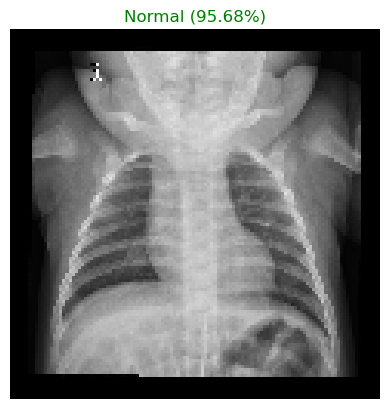

In [ ]:
import numpy as np
import random
import os
from keras.preprocessing import image
import matplotlib.pyplot as plt

# Path to your test dataset folder
test_folder = "./chest_xray/test/NORMAL/"

# Pick a random image from the test folder
random_file = random.choice(os.listdir(test_folder))
img_path = os.path.join(test_folder, random_file)

# Load and resize the image
img = image.load_img(img_path, target_size=(120, 120))

# Convert to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Normalize if needed
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

# Show image and prediction
plt.imshow(img)
plt.axis("off")

if prediction[0][0] >= 0.5:
    plt.title(f"Pneumonia ({prediction[0][0]*100:.2f}%)", color="red")
else:
    plt.title(f"Normal ({(1-prediction[0][0])*100:.2f}%)", color="green")

plt.show()


In [43]:
model.save('cnn_model.keras')  # This will replace the old saved model

In [8]:
from keras.models import load_model
modelold = load_model('cnn_model.keras')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


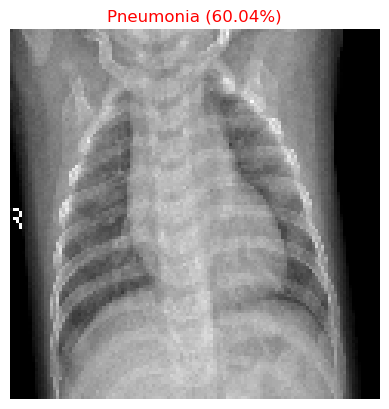

In [9]:
import numpy as np
import random
import os
from keras.preprocessing import image
import matplotlib.pyplot as plt

# Path to your test dataset folder
test_folder = "./chest_xray/test/NORMAL/"

# Pick a random image from the test folder
random_file = random.choice(os.listdir(test_folder))
img_path = os.path.join(test_folder, random_file)

# Load and resize the image
img = image.load_img(img_path, target_size=(120, 120))

# Convert to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Normalize if needed
img_array = img_array / 255.0

# Predict
prediction = modelold.predict(img_array)

# Show image and prediction
plt.imshow(img)
plt.axis("off")

if prediction[0][0] >= 0.5:
    plt.title(f"Pneumonia ({prediction[0][0]*100:.2f}%)", color="red")
else:
    plt.title(f"Normal ({(1-prediction[0][0])*100:.2f}%)", color="green")

plt.show()


In [ ]:
from keras.preprocessing.image import ImageDataGenerator
test_dir = "./chest_xray/test/"
test_generator = ImageDataGenerator(rescale=1/255)
data_test = test_generator.flow_from_directory(test_dir, target_size=(120,120), batch_size=8, class_mode="binary")
modelold.evaluate(data_test)

Found 625 images belonging to 2 classes.
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - acc: 0.8192 - loss: 0.7439


[0.7438793182373047, 0.8191999793052673]